# Phase 0 — Audio Pre-processing & SNR-mixed Dataset

This notebook loads the raw audio files, builds the composite clean signal,
loops the background noise, and generates mixes at SNR ∈ {−5, 0, 5, 10, 15} dB.

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
from audio_io import (load_mono_16k, loop_to_length, mix_at_snr, peak_normalize, save_wav, build_dataset, TARGET_SR)

AUDIO_DIR = pathlib.Path.cwd().parent / 'Audios'
OUT_DIR   = pathlib.Path.cwd().parent / 'data' / 'synth'
SNRS      = [-5, 0, 5, 10, 15]

## 1. Build the dataset

In [ ]:
paths, clean, noise = build_dataset(AUDIO_DIR, OUT_DIR, SNRS)
for k, v in paths.items():
    print(f'  {k}: {v}')

/Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Clean signal: 7325760 samples  (457.86 s)
Looped noise: 7325760 samples
  clean: /Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/data/synth/clean.wav
  snr-5dB: /Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/data/synth/mix_snr-5dB.wav
  snr+0dB: /Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/data/synth/mix_snr+0dB.wav
  snr+5dB: /Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/data/synth/mix_snr+5dB.wav
  snr+10dB: /Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/data/synth/mix_snr+10dB.wav
  snr+15dB: /Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/data/synth/mix_snr+15dB.wav


## 2. RMS sanity check

In [3]:
for snr in SNRS:
    z = mix_at_snr(clean, noise, snr)
    actual_snr = 10 * np.log10(np.mean(clean**2) / np.mean((z - clean)**2))
    print(f'Target SNR = {snr:+3d} dB  |  Measured SNR = {actual_snr:+.2f} dB')

Target SNR =  -5 dB  |  Measured SNR = -5.00 dB
Target SNR =  +0 dB  |  Measured SNR = +0.00 dB
Target SNR =  +5 dB  |  Measured SNR = +5.00 dB
Target SNR = +10 dB  |  Measured SNR = +10.00 dB
Target SNR = +15 dB  |  Measured SNR = +15.00 dB


## 3. Spectrograms

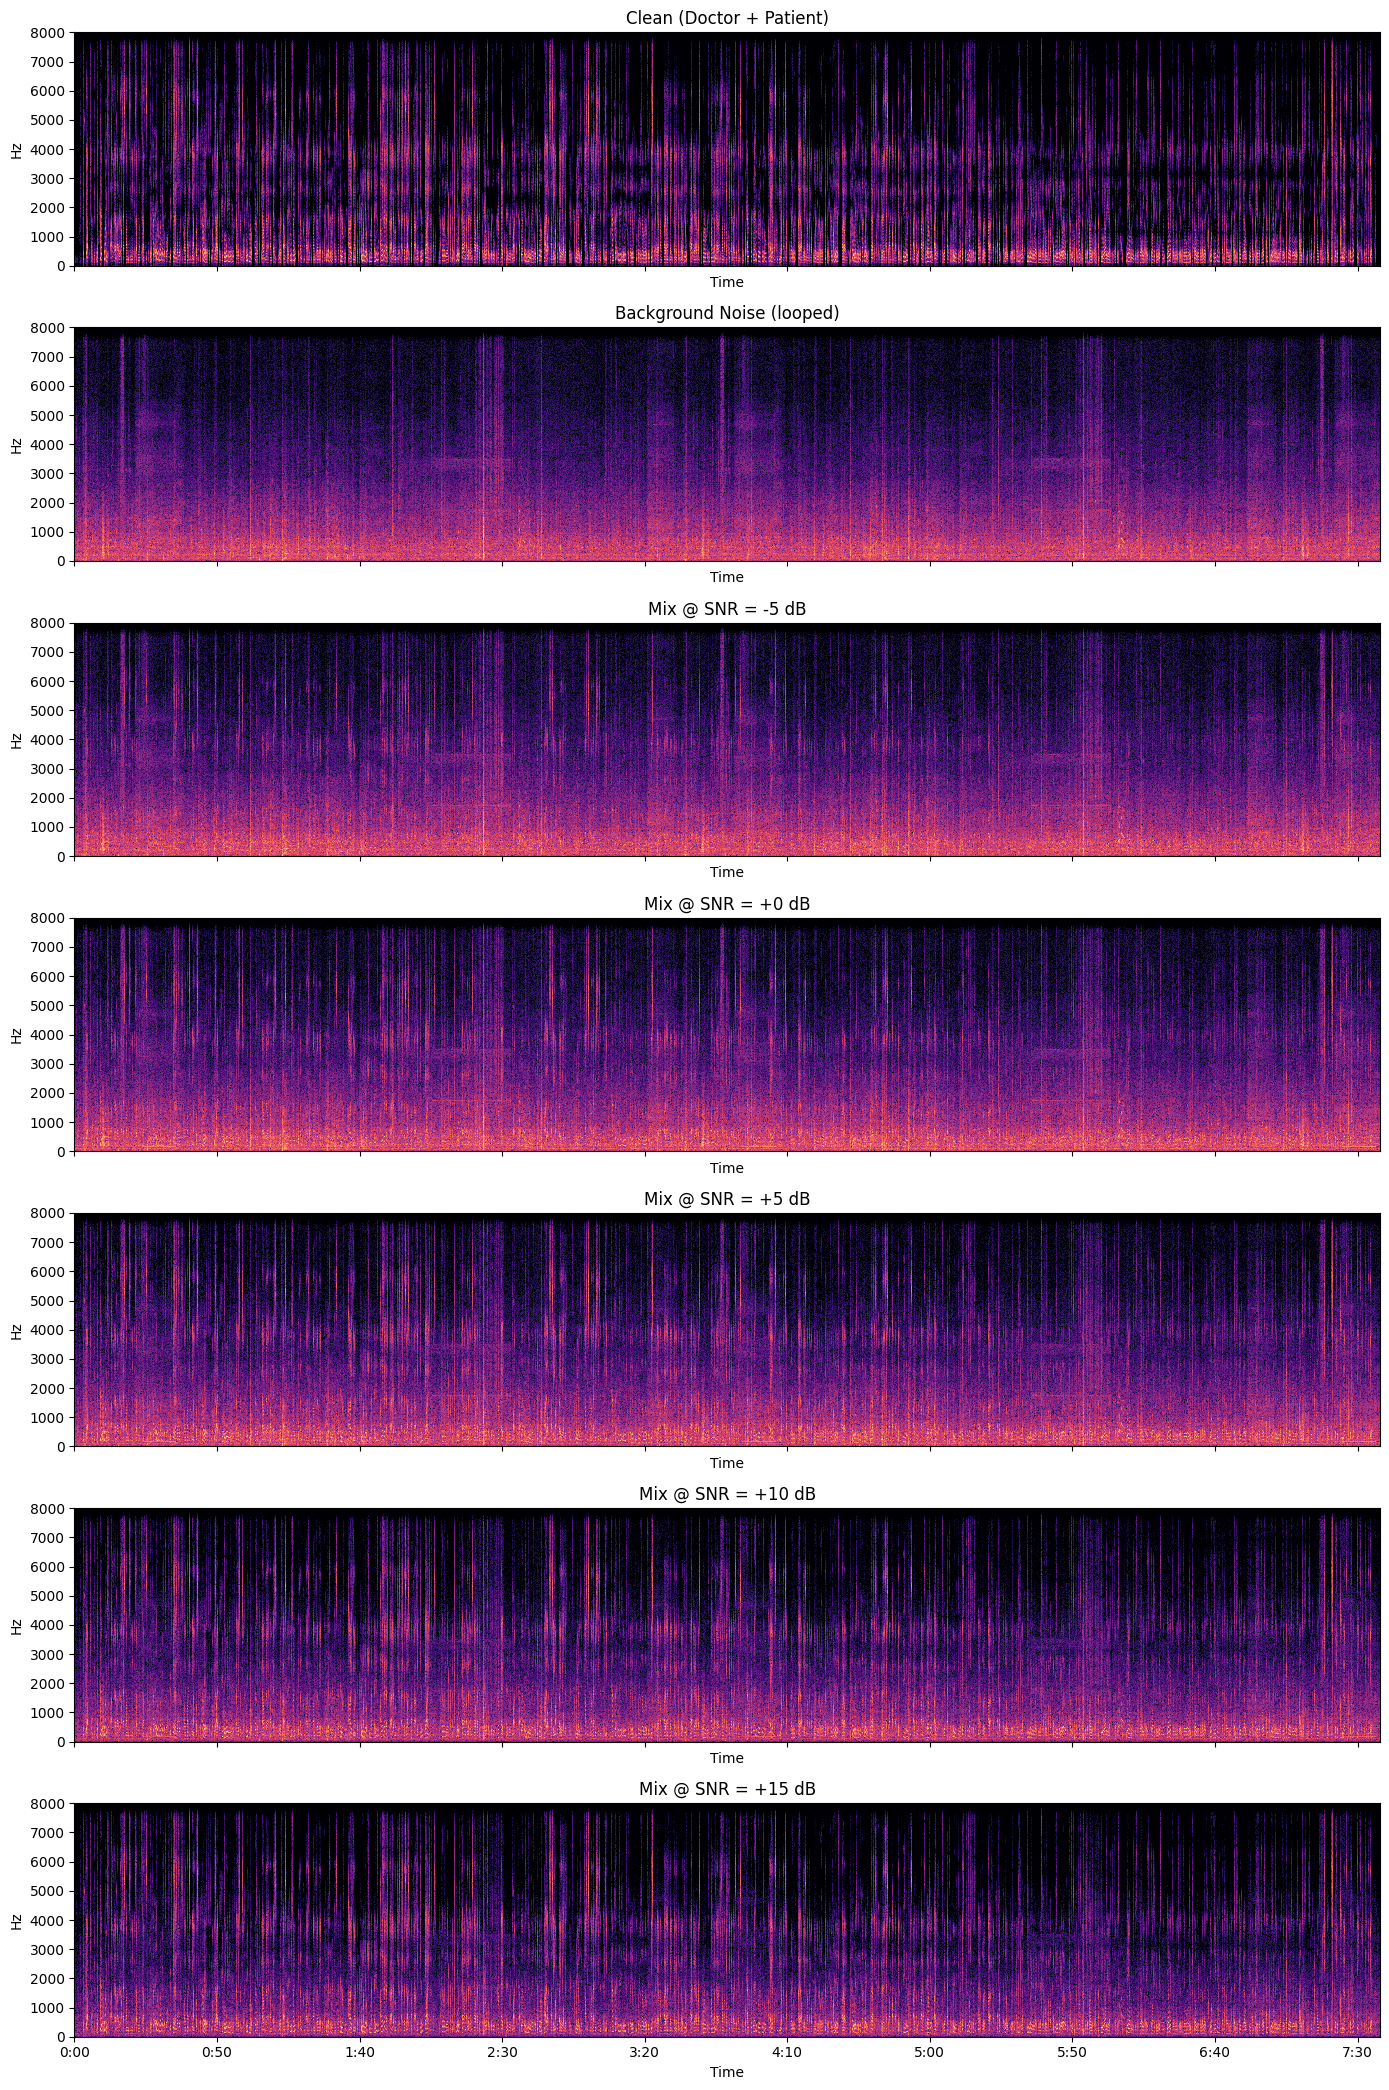

In [ ]:
fig, axes = plt.subplots(2 + len(SNRS), 1, figsize=(14, 3 * (2 + len(SNRS))), sharex=True)

def plot_spec(ax, sig, title):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)  # STFT, matrix S[f,m]: energy of frequency bin f at time frame m
    librosa.display.specshow(S, sr=TARGET_SR, x_axis='time', y_axis='hz', ax=ax)  # Display the spectrogram
    ax.set_title(title)
    ax.set_ylim(0, 8000)

plot_spec(axes[0], clean, 'Clean (Doctor + Patient)')
plot_spec(axes[1], noise, 'Background Noise (looped)')

for i, snr in enumerate(SNRS):
    z = mix_at_snr(clean, noise, snr)
    z = peak_normalize(z)
    plot_spec(axes[2 + i], z, f'Mix @ SNR = {snr:+d} dB')

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'spectrograms_phase0.png'), dpi=150)
plt.show()

## 4. Waveform overlay (5-second excerpt)

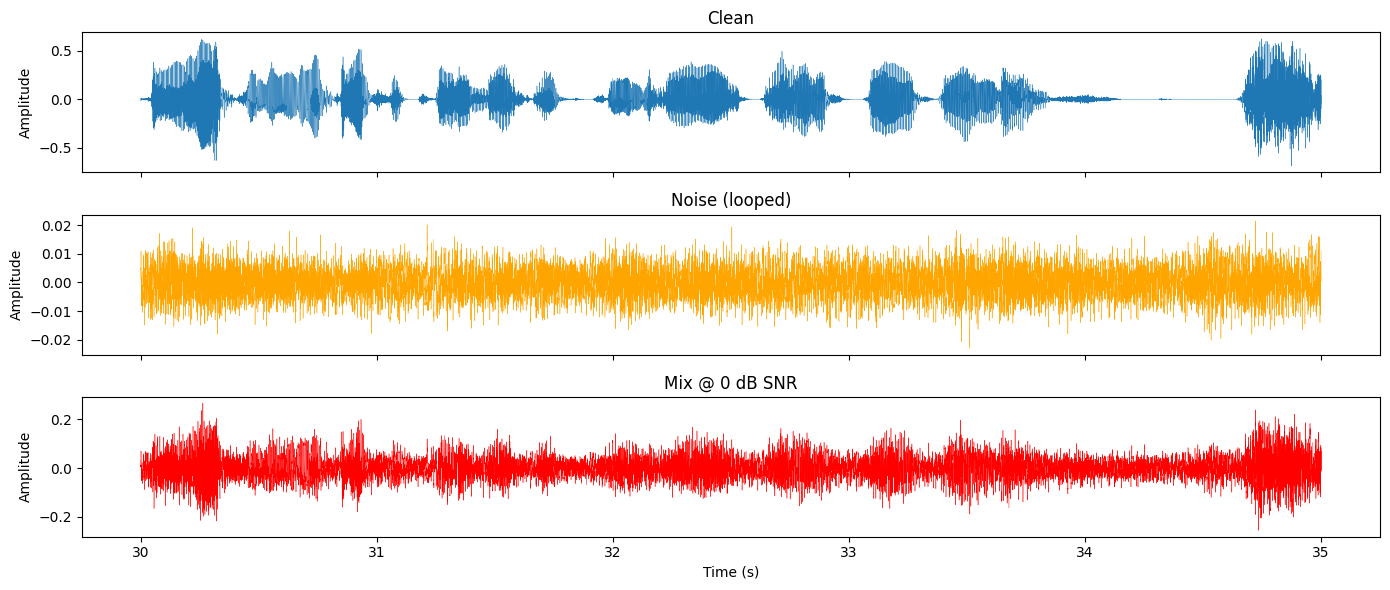

In [ ]:
start, dur = 30 * TARGET_SR, 5 * TARGET_SR
t = np.arange(dur) / TARGET_SR + 30 # From 30 seconds to 35 seconds

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, clean[start:start+dur], linewidth=0.3)
axes[0].set_title('Clean')
axes[1].plot(t, noise[start:start+dur], linewidth=0.3, color='orange')
axes[1].set_title('Noise (looped)')
z0 = peak_normalize(mix_at_snr(clean, noise, 0))
axes[2].plot(t, z0[start:start+dur], linewidth=0.3, color='red')
axes[2].set_title('Mix @ 0 dB SNR')
for ax in axes:
    ax.set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'waveforms_phase0.png'), dpi=150)
plt.show()